In [1]:
from datascience import * 
import matplotlib
import numpy as np
import matplotlib.pyplot as plots
path_data = '../../data/data8/'
matplotlib.use('Agg')
%matplotlib inline
plots.style.use('fivethirtyeight')

In [18]:
united = Table.read_table(path_data + "united_summer2015.csv")
united

Date,Flight Number,Destination,Delay
6/1/15,73,HNL,257
6/1/15,217,EWR,28
6/1/15,237,STL,-3
6/1/15,250,SAN,0
6/1/15,267,PHL,64
6/1/15,273,SEA,-6
6/1/15,278,SEA,-8
6/1/15,292,EWR,12
6/1/15,300,HNL,20
6/1/15,317,IND,-10


In [19]:
# Let's see the delays
united.column("Delay").min()

-16

In [20]:
# Let's see the delays
united.column("Delay").max()

580

In [22]:
united.where("Delay", are.above(250)).show()

Date,Flight Number,Destination,Delay
6/1/15,73,HNL,257
6/1/15,760,JFK,352
6/1/15,898,JFK,290
6/2/15,292,EWR,262
6/2/15,317,IND,312
6/3/15,73,HNL,354
6/3/15,433,LAX,318
6/4/15,1149,IAD,342
6/4/15,1743,LAX,408
6/6/15,1721,KOA,313


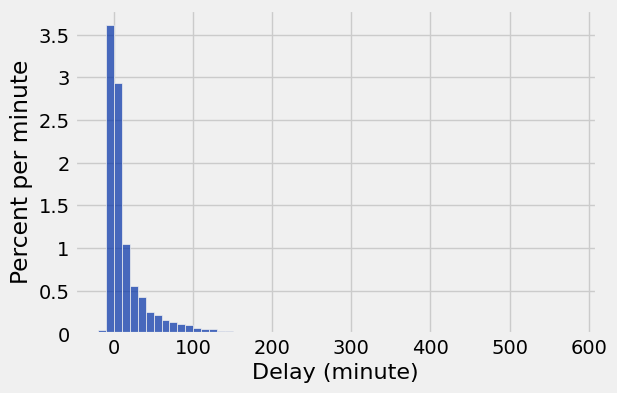

In [31]:
# A histogram perhaps
# because there's a majority of the delays under 300
# yet you could change the bins to show you more
delay_bins = np.arange(-20, 590, 10)
united.hist("Delay", bins=delay_bins, unit="minute")
# by playing with the bins we see that the bulk are under 140.

In [32]:
# what percentage of the delays are above 200 minutes
united.where("Delay", are.above(200)).num_rows/united.num_rows

0.008390596745027125

Answer = 0.8%

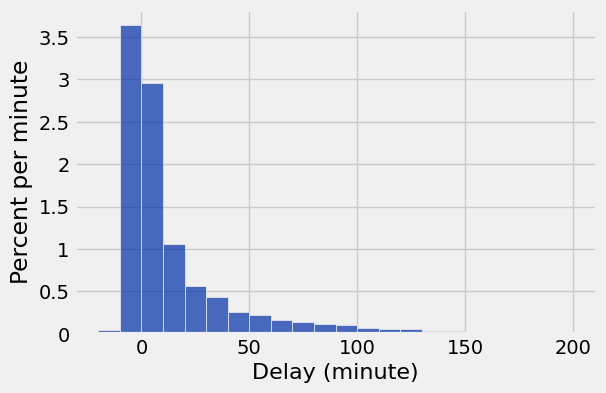

In [33]:
delay_bins = np.arange(-20, 201, 10)
united.hist("Delay", bins=delay_bins,unit="minute")

In [34]:
united.where('Delay', are.between(0, 10)).num_rows/united.num_rows

0.2935985533453888

This means that where the height of the bar is under 3% per minute - the [0, 10) bars the delays were between 0 and 10 minutes.

## Empirical distribution of the delay sample
We'll consider the flights as a population and draw random samples from it.

In [35]:
def empirical_hist_delay(n):
    united.sample(n).hist("Delay", bins=delay_bins, unit="minute")

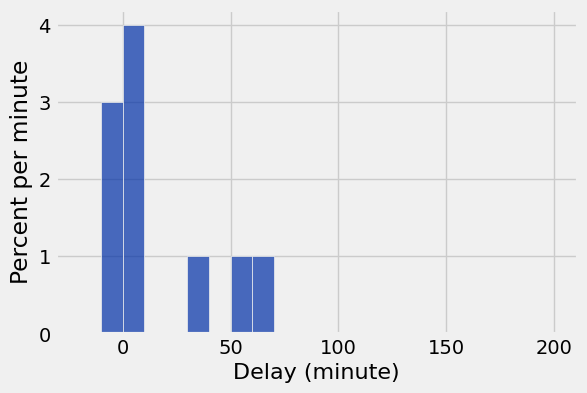

In [36]:
empirical_hist_delay(10)

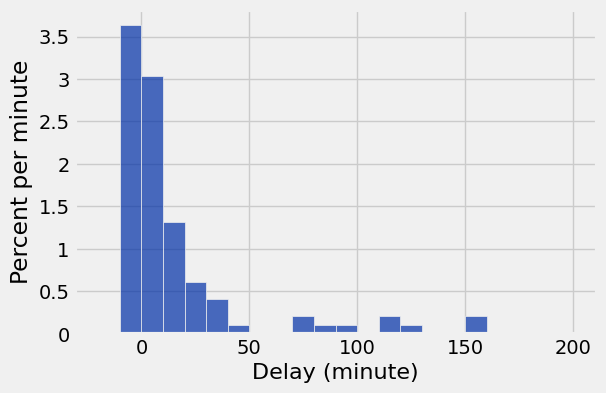

In [37]:
empirical_hist_delay(100)

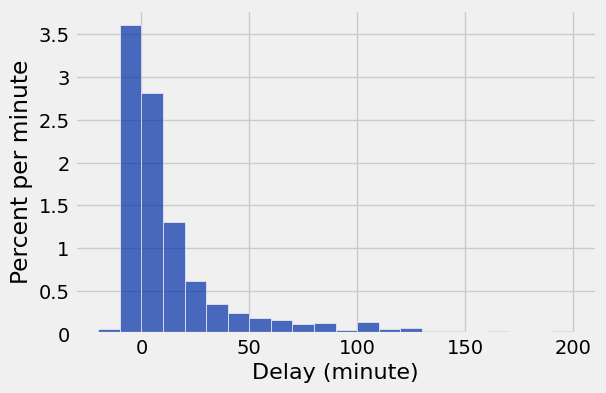

In [38]:
empirical_hist_delay(1000)

## Convergence of the Empirical Histogram of the Sample

What we have observed in this section can be summarized as follows:

For a large random sample, the empirical histogram of the sample resembles the histogram of the population, with high probability.

This justifies the use of large random samples in statistical inference.

The idea is that since a large random sample is likely to resemble the population from which it is drawn, quantities computed from the values in the sample are likely to be close to the corresponding quantities in the population.

## Parameter vs Statistic

A quantity associated with the population is a _parameter_.

One associated with a sample drawn from the population is  a _statistic_.

In [39]:
# parameter
np.median(united.column("Delay"))

2.0

In [40]:
united.where("Delay", are.below_or_equal_to(2)).num_rows / united.num_rows

0.5018444846292948

Half of the flights in the population had their flights at 2 minutes delay or less. Hence the median is 2 minutes as the half point.

In [41]:
united.where("Delay", are.equal_to(2)).num_rows
# exactly 2 minute delay

480

Text(0.5, 1.0, 'Sample size 1000')

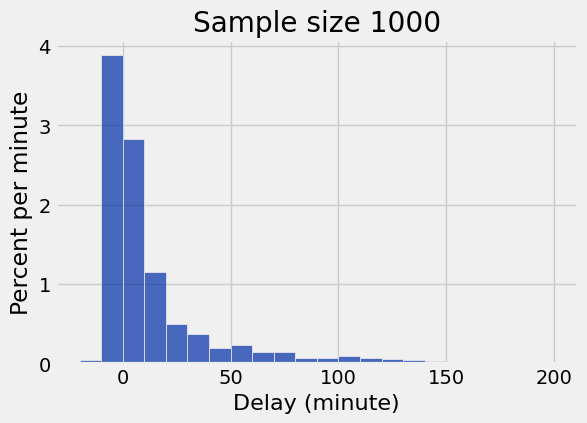

In [42]:
sample_1000 = united.sample(1000)
sample_1000.hist("Delay", bins = delay_bins, unit="minute")
plots.title("Sample size 1000")

## Statistic

In [44]:
np.median(sample_1000.column("Delay"))

2.0

The statistic could have been different. A fundamental consideration in using any statistic based on a random sample is that the sample could have come out differently, and therefore the statistic could have come out differently too.

In [48]:
np.median(united.sample(1000).column("Delay"))

3.0

When you run the above cell several times, you would indeed get different answers. Sometimes we get 2.0 which is the population parameter (median), but also 3.0. Remember that for the population, it's a parameter while for the sample, it's a statistic.

## Simulating a statistic

In order to find out how different the statistic could have been we have to run several simulations from the sample and take the value at each of these simulations. 

When we run it enough times, we will see the distribution of the statistic.

In [49]:
def random_sample_median():
    return np.median(united.sample(1000).column("Delay"))

In [50]:
medians = make_array()

# running 5000 simulations
for i in np.arange(5000):
    medians = np.append(medians, random_sample_median())

### Visualising the simulation

In [51]:
simulated_medians = Table().with_column("Sample Median", medians)
simulated_medians

Sample Median
2
3
2
2
3
2
3
2
3
2


### Visualise 
the empirical histogram of the statistic 
which displays its empirical (observed) distribution.

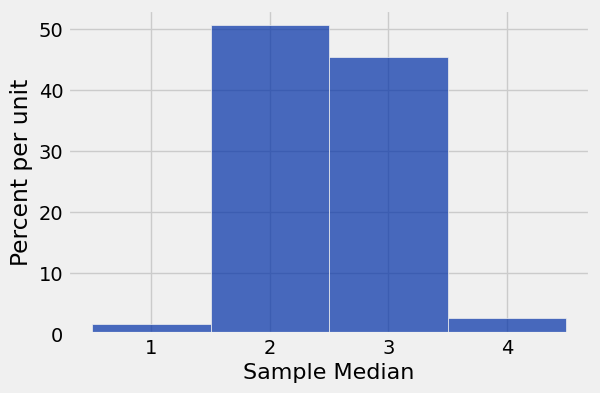

In [52]:
simulated_medians.hist(bins=np.arange(0.5, 5, 1))

We see that the sample median is likely to be about 2.0 which is the same as the population median parameter.

This is how a statistic can provide a good estimate of the parameter.

### Simulations
If we could generate all possible random samples of size 1000, we would know all possible values of the statistic (the sample median), as well as the probabilities of all those values. We could visualize all the values and probabilities in the probability histogram of the statistic.

This is where empirical histograms come in.

We know that by the Law of Averages, the empirical histogram of the statistic is likely to resemble the probability histogram of the statistic, if the sample size is large and if you repeat the random sampling process numerous times.

This means that simulating random processes repeatedly is a way of approximating probability distributions without figuring out the probabilities mathematically or generating all possible random samples. 